# Change detection in optical satellite time series - Tutorial

<div align="center">
  
  <!-- Institution Logos -->
  <img src="https://www.umr-lastig.fr/static/lastig_1920_EN-5022e6685c1e4b6d7e84d2a08667be4e.png" height="60" alt="LASTIG">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://iadf-school.org/wp-content/uploads/2022/09/logo_iadfschool.png" height="60" alt="IADF School">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://design-system.ign.fr/img/styleguide/sg_logos/IGN_logo_RVB.png" height="60" alt="IGN">
  
  <br><br>
  
  <!-- Colab Badge -->
  [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElliotVincent/iadf_tutorial/blob/main/tutorial_2.ipynb)
  
  
</div>

---

## **Tutorial 2: Training and Evaluating bi- and multi-temporal change detection models**

**Welcome to Tutorial 2!** In this hands-on session, you will learn how to train and evaluate bi- and multi-temporal change detection models for optical satellite image time series (SITS).

### What You'll Learn
- Working with a toy dataset of Planet multispectral imagery
-
- Train a semantic segmentation model
- Evaluating model performance in a post-classification framework
- Practical implementation in Google Colab

### Prerequisites
- Basic knowledge of Python and deep learning
- Familiarity with remote sensing concepts
- Google account for Colab access

---

## Introduction

This tutorial demonstrates how to perform change detection in optical satellite time series using Python.  
We will use a sample dataset of satellite images and apply various techniques to identify changes over time.  
The sample dataset is extracted from DynamicEarthNet [1] and focuses on 3 AoIs.  
The map below shows the location of the 3 AoIs in the world:  


![Map of the 3 AoIs](https://github.com/ElliotVincent/iadf_tutorial/blob/main/aois_location.png?raw=1)


In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import random
import rasterio
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
!pip install segmentation_models_pytorch
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.base import SegmentationModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.9 MB/s eta 0:00:00


## 1. Playing with Satellite Image Time Series

### 1.1. Loading and Visualizing the Dataset

In [2]:
DYNAMICEARTHNET_CLASSES = {
    0: {"label": "other",                     "color": (128, 128, 128)},  # grey
    1: {"label": "vegetation",                "color": ( 34, 139,  34)},  # green
    2: {"label": "water",                     "color": ( 31, 119, 180)},  # blue
}

DATES = [f"{yyyy}-{mm:02d}-01" for yyyy in range(2018, 2020) for mm in range(1, 13)]

# Utility function to perform percentile stretching on the image for better visualization
def percentile_stretch(img, low=2, high=98):
    lo, hi = np.percentile(img, (low, high))
    img_clipped = np.clip(img, lo, hi)
    return ((img_clipped - lo) / (hi - lo) * 255).astype(np.uint8)

# Function to plot a single image
def plot_image(image):
    rgb_img = image[:3]
    rgb_img = rgb_img.transpose(1, 2, 0)
    rgb_img = percentile_stretch(rgb_img)
    plt.imshow(rgb_img)
    plt.axis('off')

# Function to plot a single label
def plot_labels(label):
    rgb_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for i in range(3):
        rgb_label[label == i] = DYNAMICEARTHNET_CLASSES[i]["color"]
    plt.imshow(rgb_label)
    plt.axis('off')

# Function to plot a time series of images and labels
def plot_time_series(images, labels, num_images=10):
    num_images = min(num_images, len(images))
    fig, axes = plt.subplots(3, num_images, figsize=(int(4*num_images / 3), 4))
    for i in range(num_images):
        # Plot the image
        rgb_img = images[i, :3].transpose(1, 2, 0)
        rgb_img = percentile_stretch(rgb_img)
        axes[0, i].set_title(DATES[i], fontsize=10)
        axes[0, i].imshow(rgb_img)
        axes[0, i].axis('off')

        # Plot the semantic maps
        rgb_label = np.zeros((labels[i].shape[0], labels[i].shape[1], 3), dtype=np.uint8)
        for j in range(3):
            rgb_label[labels[i] == j] = DYNAMICEARTHNET_CLASSES[j]["color"]
        axes[1, i].imshow(rgb_label)
        axes[1, i].axis('off')

        # Plot binary change maps
        if i > 0:
            change_map = (labels[i] != labels[i-1]).astype(np.uint8) * 255
            axes[2, i].imshow(change_map, cmap='gray')
            axes[2, i].axis('off')
        else:
            axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

def load_time_series(path):
    return np.stack([rasterio.open(f"{path}/{date}.tif").read() for date in DATES], axis=0)[:, [2, 1, 0, 3]]

def load_labels(path):
    labels = np.load(f'{path}.npy')
    labels = np.where(labels == 2, 1, labels)
    labels = np.where(labels == 3, 0, labels)
    labels = np.where(labels == 4, 0, labels)
    labels = np.where(labels == 5, 2, labels)
    labels = np.where(labels == 6, 0, labels)
    return labels

We first load the sample dataset and visualize the images for each AoI.  
Satellite image time series (SITS) are stored as T x C x H x W tensors, where T is the number of time steps, C is the number of channels (spectral bands), H is the height, and W is the width of the image.  
In our case, we have 3 AoIs with T=24 (2 years of monthly images between January 2018 and December 2019), C=4 (RGB + NIR), H=1024, and W=1024.  
The spatial resolution of the images is roughly 3 meters per pixel.
DinamicEarthNet dataset is annotated with per-month semantic masks, with 7 land-cover classes: Impervious surface, Agriculture, Forest, Bare soil, Wetlands, Water, Snow/Ice.  
In this tutorial, we simplify the problem by grouping them in 3 classes:
- 0: Other (Impervious surface + Bare soil + Wetlands + Snow/Ice)
- 1: Vegetation (Agriculture + Forest)
- 2: Water (Water)

In [3]:
!gdown 12R7wzxLnyp-jAQ_97uUqlHd8AjEyTQg5
!gdown 1q4Kx2LnId-eTPW8WZ1yJWwYujlQ2CZnj
!unzip "/content/data.zip"
!unzip "/content/labels.zip"

Downloading...
From (original): https://drive.google.com/uc?id=12R7wzxLnyp-jAQ_97uUqlHd8AjEyTQg5
From (redirected): https://drive.google.com/uc?id=12R7wzxLnyp-jAQ_97uUqlHd8AjEyTQg5&confirm=t&uuid=9c5ed7af-ec71-4504-b2a4-a436d7693505
To: /content/data.zip
100% 537M/537M [00:15<00:00, 35.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1q4Kx2LnId-eTPW8WZ1yJWwYujlQ2CZnj
To: /content/labels.zip
100% 4.61M/4.61M [00:00<00:00, 12.3MB/s]
Archive:  /content/data.zip
   creating: 3998_3016_13/
  inflating: 3998_3016_13/2019-07-01.tif  
  inflating: 3998_3016_13/2018-01-01.tif  
  inflating: 3998_3016_13/2019-01-01.tif  
  inflating: 3998_3016_13/2018-02-01.tif  
  inflating: 3998_3016_13/2018-03-01.tif  
  inflating: 3998_3016_13/2018-04-01.tif  
  inflating: 3998_3016_13/2018-05-01.tif  
  inflating: 3998_3016_13/2018-06-01.tif  
  inflating: 3998_3016_13/2018-07-01.tif  
  inflating: 3998_3016_13/2018-08-01.tif  
  inflating: 3998_3016_13/2018-09-01.tif  
  inflating: 3998_3016_13/2

Loading aoi_1 images and labels...


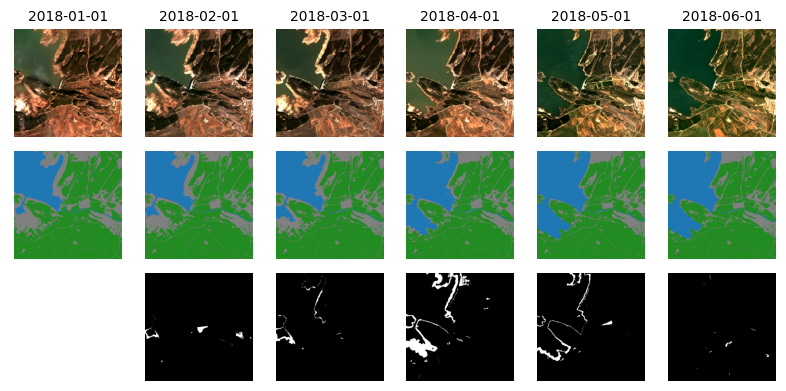

Loading aoi_2 images and labels...


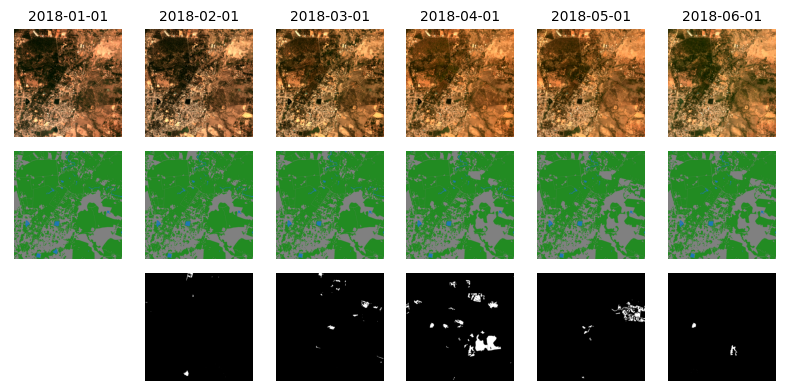

Loading aoi_3 images and labels...


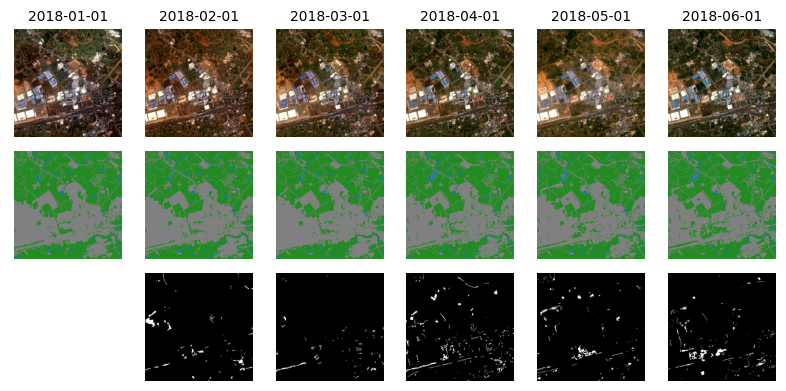

In [4]:
aoi_1 = '3998_3016_13'
aoi_2 = '5989_3554_13'
aoi_3 = '6468_3360_13'

print(f"Loading aoi_1 images and labels...")
aoi_1_images = load_time_series(aoi_1)
aoi_1_labels = load_labels(aoi_1)
plot_time_series(aoi_1_images, aoi_1_labels, num_images=6)

print(f"Loading aoi_2 images and labels...")
aoi_2_images = load_time_series(aoi_2)
aoi_2_labels = load_labels(aoi_2)
plot_time_series(aoi_2_images, aoi_2_labels, num_images=6)

print(f"Loading aoi_3 images and labels...")
aoi_3_images = load_time_series(aoi_3)
aoi_3_labels = load_labels(aoi_3)
plot_time_series(aoi_3_images, aoi_3_labels, num_images=6)


Let's check the shape of each SITS tensor.

In [5]:
print(f"AOI 1 images shape: {aoi_1_images.shape}, AOI 1 labels shape: {aoi_1_labels.shape}")
print(f"AOI 2 images shape: {aoi_2_images.shape}, AOI 2 labels shape: {aoi_2_labels.shape}")
print(f"AOI 3 images shape: {aoi_3_images.shape}, AOI 3 labels shape: {aoi_3_labels.shape}")

AOI 1 images shape: (24, 4, 1024, 1024), AOI 1 labels shape: (24, 1024, 1024)
AOI 2 images shape: (24, 4, 1024, 1024), AOI 2 labels shape: (24, 1024, 1024)
AOI 3 images shape: (24, 4, 1024, 1024), AOI 3 labels shape: (24, 1024, 1024)


In [6]:
class SITSDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels, split, norm=True, num_classes=3, augment=False):
        # Load the dataset once in memory
        self.data = data
        self.labels = labels
        self.norm = norm
        # Dataset statistics for normalization, from DynamicEarthNet paper
        self.mean = torch.tensor([1042.59, 915.62, 671.26, 2605.21])
        self.std = torch.tensor([957.96, 715.55, 596.94, 1059.90])
        self.num_classes = num_classes
        self.ij_lists = {"train":[[i, j] for i in range(16) for j in range(16) if i < 12],
                         "val": [[i, j] for i in range(16) for j in range(16) if i >= 12 and j < 8],
                         "test": [[i, j] for i in range(16) for j in range(16) if i >= 12 and j >= 8]}[split]
        self.split = split
        self.augment = augment

    def __len__(self):
        return len(self.ij_lists) * 3

    def __getitem__(self, idx):
        aoi = idx % 3
        idx = idx // 3
        i, j = self.ij_lists[idx]
        x, y = i*64, j*64
        if self.split == 'train' and self.augment:
          # random crop
          x = min(x + random.randint(0, 63), 11 * 64)
          y = min(y + random.randint(0, 63), 15 * 64)
        imgs = torch.tensor(self.data[aoi][..., x:x+64, y:y+64])
        labs = torch.tensor(self.labels[aoi][..., x:x+64, y:y+64])
        if self.norm:
            imgs = (imgs - self.mean[:, None, None]) / self.std[:, None, None]
        if self.augment:
            # random rotation
            rot = random.randint(0, 3)
            imgs = torch.rot90(imgs, rot, [2, 3])
            labs = torch.rot90(labs, rot, [1, 2])
            # random flip
            flip = random.randint(0, 1)
            if flip == 1:
                imgs = torch.flip(imgs, [2])
                labs = torch.flip(labs, [1])
        return imgs, labs


In [7]:
train_set = SITSDataset(data=[aoi_1_images, aoi_2_images, aoi_3_images],
                        labels=[aoi_1_labels, aoi_2_labels, aoi_3_labels],
                        split='train', norm=True, num_classes=3, augment=True)

val_set = SITSDataset(data=[aoi_1_images, aoi_2_images, aoi_3_images],
                      labels=[aoi_1_labels, aoi_2_labels, aoi_3_labels],
                      split='val', norm=True, num_classes=3)

test_set = SITSDataset(data=[aoi_1_images, aoi_2_images, aoi_3_images],
                      labels=[aoi_1_labels, aoi_2_labels, aoi_3_labels],
                      split='test', norm=True, num_classes=3)

In [8]:
def new_forward(self, x, return_features=False, sem_features=None):
    features = self.encoder(x)
    if sem_features is not None:
        sem1, sem2 = sem_features
        for (i,feat) in enumerate(features):
            if i>0:
                features[i] = feat + sem1[i] - sem2[i]
    decoder_output = self.decoder(features)
    masks = self.segmentation_head(decoder_output)
    if return_features:
        return masks, features
    else:
        return masks

SegmentationModel.forward = new_forward

class DualUnet(nn.Module):
    def __init__(self, backbone="mobilenet_v2", in_channels=4, num_classes=3):
        super(DualUnet, self).__init__()
        self.in_channels = in_channels
        self.change_model = smp.Unet(encoder_name=backbone, encoder_weights="imagenet" , in_channels=in_channels * 2, classes=2)
        self.seg_model = smp.Unet(encoder_name=backbone, encoder_weights="imagenet", in_channels=in_channels, classes=num_classes)

    def forward(self, x):
        y1, f1 = self.seg_model(x[0], return_features=True)
        y2, f2 = self.seg_model(x[1], return_features=True)
        sem_preds = (y1, y2)
        change_pred = self.change_model(torch.cat([x[0], x[1]], dim=1), sem_features=(f1, f2))
        return change_pred, sem_preds

model = DualUnet()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Model parameters: 13,260,053


In [28]:
def compute_metrics(confusion_matrix):
    # Compute overall accuracy
    overall_accuracy = torch.trace(confusion_matrix) / torch.sum(confusion_matrix)

    # Compute mean IoU
    intersection = torch.diagonal(confusion_matrix)
    union = torch.sum(confusion_matrix, dim=1) + torch.sum(confusion_matrix, dim=0) - intersection
    mean_iou = torch.mean(intersection / union)

    return overall_accuracy, mean_iou
import torchvision

def training_step(batch, model, criterion, optimizer, device):
    imgs, labs = batch
    imgs = imgs.to(device)
    labs = labs.to(device)
    # imgs of shape (B, T, C, H, W)
    optimizer.zero_grad()
    temp_indices = torch.tensor([random.sample(range(imgs.size(1)), 2) for _ in range(imgs.size(0))], device=imgs.device)  # (B, 2)
    batch_idx = torch.arange(imgs.size(0), device=imgs.device)[:, None]
    imgs, labs = imgs[batch_idx, temp_indices], labs[batch_idx, temp_indices]
    change_logits, sem_logits = model([imgs[:, 0], imgs[:, 1]])
    change_gt = nn.functional.one_hot((labs[:, 0] != labs[:, 1]).long(), num_classes=2).permute(0, 3, 1, 2).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits, change_gt, reduction='mean')
    loss_sem = (criterion(sem_logits[0], labs[:, 0].long()) + criterion(sem_logits[1], labs[:, 1].long())) / 2
    loss = loss_change + loss_sem
    loss.backward()
    optimizer.step()
    return loss


def validation_step(batch, model, criterion, device):
    imgs, labs = batch
    imgs = imgs.to(device).squeeze(0)
    labs = labs.to(device).squeeze(0)
    # imgs of shape (1, T, C, H, W)
    imgs = torch.stack([imgs[:-1], imgs[1:]], dim=1)
    change_logits, sem_logits = model([imgs[:, 0], imgs[:, 1]])
    change_gt = nn.functional.one_hot((labs[:-1] != labs[1:]).long(), num_classes=2).permute(0, 3, 1, 2).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits, change_gt, reduction='mean')
    loss_sem = (criterion(sem_logits[0], labs[:-1].long()) + criterion(sem_logits[1], labs[1:].long())) / 2
    loss = loss_change + loss_sem
    pred_change = torch.argmax(change_logits, dim=1)
    pred_sem = torch.argmax(sem_logits[0], dim=1), torch.argmax(sem_logits[1], dim=1)
    return loss, pred_change, pred_sem, (labs[:-1] != labs[1:]).long(), (labs[:-1], labs[1:])

In [29]:
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)
model = DualUnet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
device = 'cuda'
model.to(device)

logs = {"train_loss": [], "val_loss": [], "val_acc": [], "val_miou": [], "val_acc_change": [], "val_miou_change": []}
best_val_miou_change = 0.0
best_model_change = None
best_model_val_conf_matrix = None
best_model_val_conf_matrix_change = None
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    avg_train_loss = 0.0
    for batch in train_loader:
        loss = training_step(batch, model, criterion, optimizer, device)
        avg_train_loss += loss.item()
    avg_train_loss /= len(train_loader)
    print(f"   Average Training Loss: {avg_train_loss:.4f}")
    model.eval()
    avg_val_loss = 0.0
    val_conf_matrix = torch.zeros(3, 3, dtype=torch.long, device=device)
    with torch.no_grad():
        for batch in val_loader:
            loss, pred_change, pred_sem, labs_change, labs_sem = validation_step(batch, model, criterion, device)
            avg_val_loss += loss.item()
            val_conf_matrix += torch.bincount(pred_sem[1].flatten().long() * 3 + labs_sem[1].flatten().long(), minlength=9).reshape(3, 3)
            val_conf_matrix_change = torch.bincount(pred_change.flatten().long() * 2 + labs_change.flatten().long(), minlength=4).reshape(2, 2)
    avg_val_loss /= len(val_loader)
    acc, miou = compute_metrics(val_conf_matrix)
    acc_change, miou_change = compute_metrics(val_conf_matrix_change)
    print(f"   Average Validation Loss: {avg_val_loss:.4f}")
    print(f"   Validation Accuracy: {acc*100:.2f}%, mIoU: {miou*100:.2f}%")
    print(f"   Change Detection Accuracy: {acc_change*100:.2f}%, Change mIoU: {miou_change*100:.2f}%")
    logs["train_loss"].append(avg_train_loss)
    logs["val_loss"].append(avg_val_loss)
    logs["val_acc"].append(acc.item())
    logs["val_miou"].append(miou.item())
    logs["val_acc_change"].append(acc_change.item())
    logs["val_miou_change"].append(miou_change.item())
    if miou_change.item() > best_val_miou_change:
        best_val_miou_change = miou_change.item()
        best_model_change = model
        best_model_val_conf_matrix = val_conf_matrix.clone()
        best_model_val_conf_matrix_change = val_conf_matrix_change.clone()
    scheduler.step()

Epoch 1/50
   Average Training Loss: 1.0436
   Average Validation Loss: 0.8128
   Validation Accuracy: 70.99%, mIoU: 40.61%
   Change Detection Accuracy: 90.12%, Change mIoU: 45.66%
Epoch 2/50
   Average Training Loss: 0.7943
   Average Validation Loss: 0.6553
   Validation Accuracy: 76.50%, mIoU: 51.13%
   Change Detection Accuracy: 97.20%, Change mIoU: 49.03%
Epoch 3/50
   Average Training Loss: 0.7038
   Average Validation Loss: 0.5913
   Validation Accuracy: 79.84%, mIoU: 60.69%
   Change Detection Accuracy: 98.74%, Change mIoU: 49.67%
Epoch 4/50
   Average Training Loss: 0.6445
   Average Validation Loss: 0.5308
   Validation Accuracy: 81.45%, mIoU: 62.39%
   Change Detection Accuracy: 98.90%, Change mIoU: 49.54%
Epoch 5/50
   Average Training Loss: 0.5905
   Average Validation Loss: 0.4982
   Validation Accuracy: 81.72%, mIoU: 65.93%
   Change Detection Accuracy: 98.90%, Change mIoU: 49.45%
Epoch 6/50
   Average Training Loss: 0.5524
   Average Validation Loss: 0.4787
   Validati

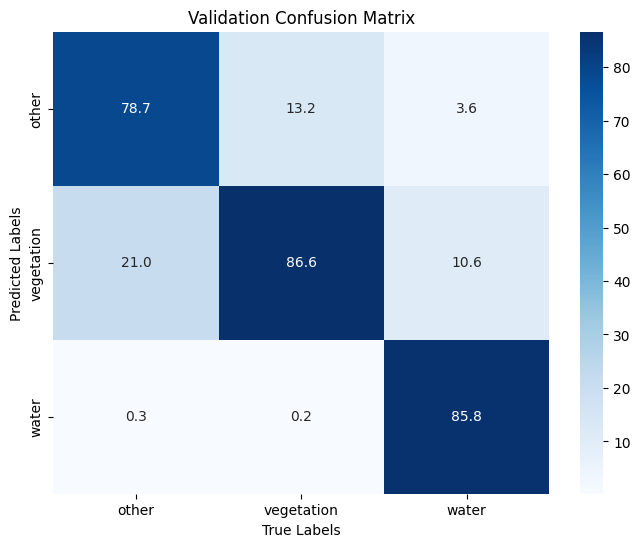

In [31]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix.float() / best_model_val_conf_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

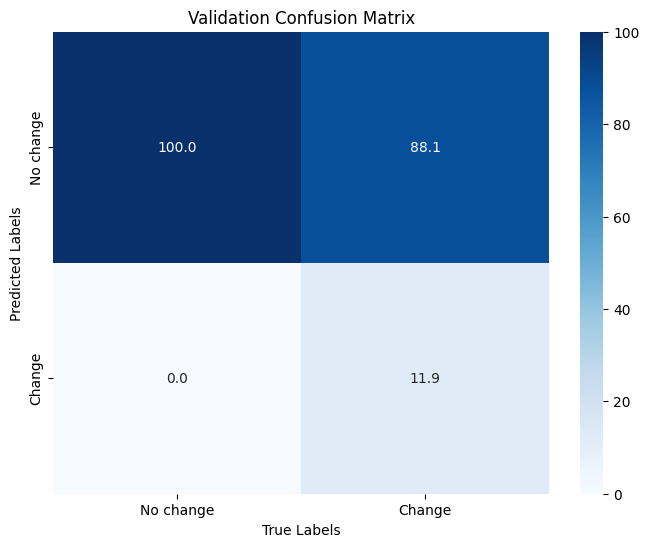

In [30]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix_change.float() / best_model_val_conf_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=["No change", "Change"], yticklabels=["No change", "Change"])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

We have trained a simple Unet model for semantic segmentation on our dataset, considering each frame independently.
We have verified that our trained model achieves correct predictions on the validation set, both quantitatively and qualitatively.  

Now, let's evaluate our model on the change detection task on the test set.

In [35]:
canva_lab = torch.zeros(3, 24, 256, 512)
canva_pred = torch.zeros(3, 24, 256, 512)
canva_lab_change = torch.zeros(3, 23, 256, 512)
canva_pred_change = torch.zeros(3, 23, 256, 512)
ij_list = [[i, j] for i in range(4) for j in range(8)]
model.eval()
for k in range(len(test_set)):
    imgs, labs = test_set[k]
    imgs = torch.stack([imgs[:-1], imgs[1:]], dim=1).to(device)
    with torch.no_grad():
        change_logits, sem_logits = best_model_change([imgs[:, 0], imgs[:, 1]])
    pred_change = torch.argmax(change_logits, dim=1).detach().cpu()
    pred_sem = torch.cat([torch.argmax(sem_logits[0], dim=1)[0][None], torch.argmax(sem_logits[1], dim=1)], dim=0).detach().cpu()
    labs = labs.detach().cpu()
    labs_change = (labs[:-1] != labs[1:]).long()
    i, j = ij_list[k//3]
    canva_lab[k%3, :, i*64:(i+1)*64, j*64:(j+1)*64] = labs
    canva_pred[k%3, :, i*64:(i+1)*64, j*64:(j+1)*64] = pred_sem
    canva_lab_change[k%3, :, i*64:(i+1)*64, j*64:(j+1)*64] = labs_change
    canva_pred_change[k%3, :, i*64:(i+1)*64, j*64:(j+1)*64] = pred_change

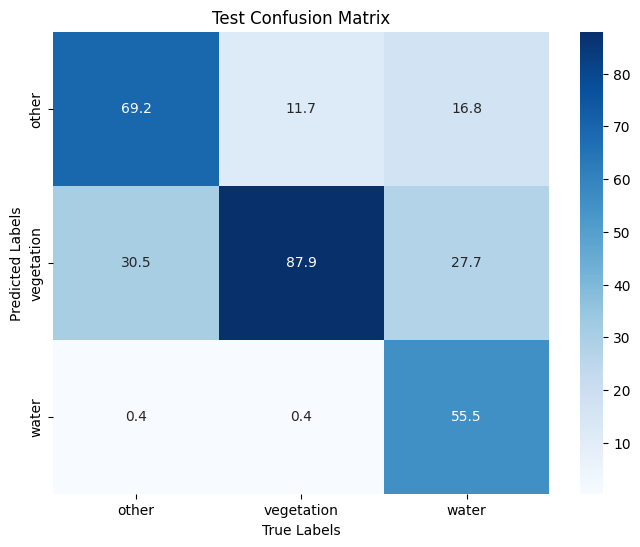

In [36]:
test_confusion_matrix = torch.bincount(canva_pred.flatten().long() * 3 + canva_lab.flatten().long(), minlength=9).reshape(3, 3)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_normalized = test_confusion_matrix.float() / test_confusion_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix')
plt.show()

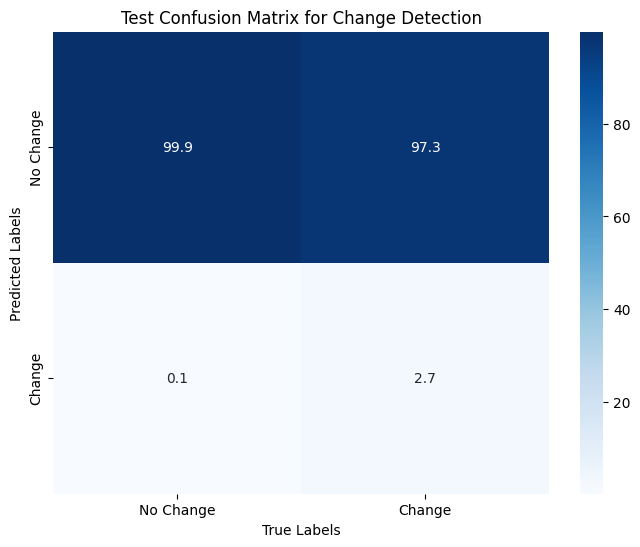

In [42]:
test_confusion_matrix_change = torch.bincount(canva_pred_change.flatten().long() * 2 + canva_lab_change.flatten().long(), minlength=4).reshape(2, 2)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_change_normalized = test_confusion_matrix_change.float() / test_confusion_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_change_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=['No Change', 'Change'], yticklabels=['No Change', 'Change'])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix for Change Detection')
plt.show()

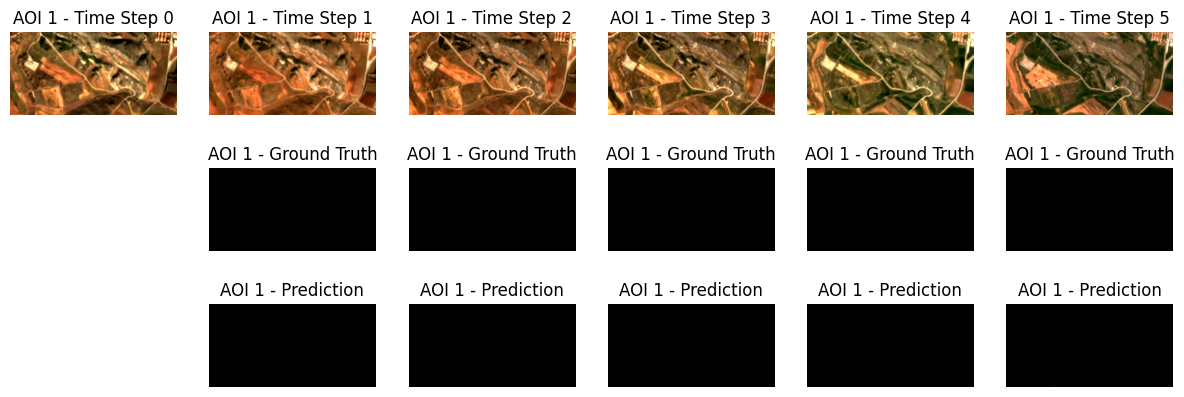

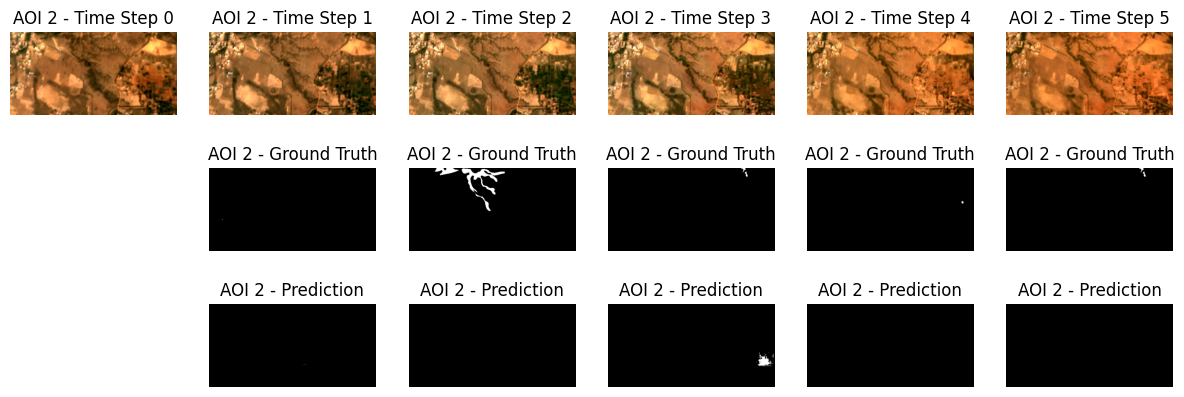

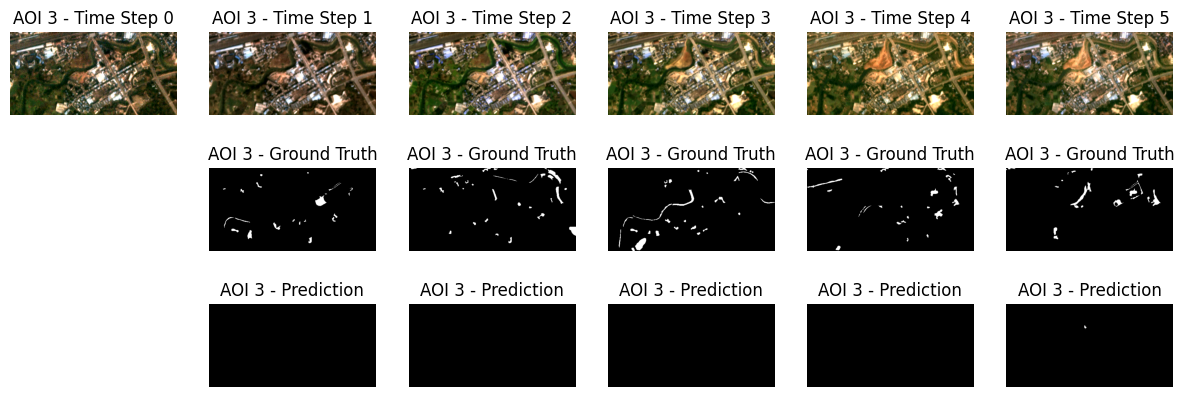

In [46]:
for aoi_id, aoi in enumerate([aoi_1_images, aoi_2_images, aoi_3_images]):
    plt.figure(figsize=(15, 5))
    for time_step in range(6):
        plt.subplot(3, 6, time_step + 1)
        plt.title(f"AOI {aoi_id+1} - Time Step {time_step}")
        plot_image(aoi[time_step+12, :, 768:, 512:])
        if time_step > 0:
            plt.subplot(3, 6, time_step + 7)
            plt.title(f"AOI {aoi_id+1} - Ground Truth")
            plt.imshow(canva_lab_change[aoi_id, time_step+12].numpy(), cmap='gray')
            plt.axis('off')
            plt.subplot(3, 6, time_step + 13)
            plt.title(f"AOI {aoi_id+1} - Prediction")
            plt.imshow(canva_pred_change[aoi_id, time_step+12].numpy(), cmap='gray')
            plt.axis('off')
    plt.show()

Looking at the predicted binary change mask, compared to the ground truth, we can observe two things:
1. Predicted change maps are very noisy, with a significant amount of false positives.  
2. Some real changes are missed by the model, leading to false negatives.  
Overall, change performance are low, as shown by the change IoU and the false positive rate.

In [ ]:
change_iou = test_confusion_matrix_change[1, 1].float() / (test_confusion_matrix_change[1, 1].float() + test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 1].float())
false_positive_rate = test_confusion_matrix_change[1, 0].float() / (test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 0].float())
print(f"Change IoU: {change_iou.item() * 100:.1f}")
print(f"False Positive Rate: {false_positive_rate.item() * 100:.1f}")

### Bibliography

[1] Toker et al. _DynamicEarthNet: Daily Multi-Spectral Satellite Dataset for Semantic Change Segmentation_. CVPR 2022.